# --- GEREKLİ KÜTÜPHANELER ---

In [ ]:
import pandas as pd # Veri setini tablo olarak işlemek için
import numpy as np # Matris dönüşümleri ve çok boyutlu diziler için
import matplotlib.pyplot as plt # Eğitim grafiklerini çizdirmek için
import seaborn as sns # Confusion Matrix'i (Karmaşıklık Matrisi) görselleştirmek için
from sklearn.preprocessing import MinMaxScaler # Veriyi 0-1 arasına ölçeklendirmek için
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix # İstenen değerlendirme metrikleri
import tensorflow as tf # Derin öğrenme motoru
from tensorflow.keras.models import Sequential, Model # Sıralı ve fonksiyonel yapay sinir ağı modelleri için
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Input # Kullanılacak katmanlar
from tensorflow.keras.callbacks import EarlyStopping # Aşırı öğrenmeyi (Overfitting) engellemek için

# --- VERİ OKUMA VE ETİKETLEME ---
# NSL-KDD veri setinin standart özellik (sütun) isimleri

In [ ]:

# --- 1. ÖZNİTELİK TANIMLAMALARI ---
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'attack_type', 'level'
]

# --- 2. VERİ SETİ YÜKLEME ---
files_in_content = os.listdir('/content/')
train_file = next((f for f in files_in_content if 'train' in f.lower()), None)
test_file = next((f for f in files_in_content if 'test' in f.lower()), None)

if train_file and test_file:
    try:
        df_train = pd.read_csv(f"/content/{train_file}", names=columns)
        df_test = pd.read_csv(f"/content/{test_file}", names=columns)

        # --- 3. ETİKETLEME VE TEMİZLEME ---
        # Binary Classification: 'normal' -> 0, anomalies -> 1
        df_train['label'] = df_train['attack_type'].apply(lambda x: 0 if x == 'normal' else 1)
        df_test['label'] = df_test['attack_type'].apply(lambda x: 0 if x == 'normal' else 1)
        df_train.drop(['attack_type', 'level'], axis=1, inplace=True)
        df_test.drop(['attack_type', 'level'], axis=1, inplace=True)

        # Kategorik verilerin One-Hot Encoding yöntemiyle dönüştürülmesi
        categorical_cols = ['protocol_type', 'service', 'flag']
        combined = pd.concat([df_train, df_test])
        combined = pd.get_dummies(combined, columns=categorical_cols, drop_first=True)

        train_proc = combined.iloc[:len(df_train)]
        test_proc = combined.iloc[len(df_train):]

        X_train = train_proc.drop('label', axis=1)
        y_train = train_proc['label']
        X_test = test_proc.drop('label', axis=1)
        y_test = test_proc['label']

        # --- 4. NORMALİZASYON VE BOYUTLANDIRMA ---
        # Verilerin 0-1 aralığına ölçeklenmesi
        scaler = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # CNN girişi için verilerin 3D tensör formatına getirilmesi (Samples, Features, 1)
        X_train_cnn = np.reshape(X_train_scaled, (X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
        X_test_cnn = np.reshape(X_test_scaled, (X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

        print(f"Veri yükleme ve ön işleme aşaması başarıyla tamamlanmıştır.")
        print(f"Eğitim seti boyutu: {X_train_cnn.shape}")

    except Exception as e:
        print(f"Dosya okuma sırasında hata oluştu: {e}")
else:
    print("Hata: Gerekli CSV dosyaları dizinde bulunamadı.")

Veri yükleme ve ön işleme aşaması başarıyla tamamlanmıştır.
Eğitim seti boyutu: (125973, 119, 1)


# ---KATEGORİK VERİLERİ SAYISALLAŞTIRMA VE ÖLÇEKLENDİRME ---

In [ ]:
categorical_cols = ['protocol_type', 'service', 'flag']
# Train ve Test setlerinde sütun sayılarının (boyutların) eşleşmesi için geçici olarak birleştiriyoruz
combined_df = pd.concat([df_train, df_test])
# (One-Hot Encoding)
combined_df = pd.get_dummies(combined_df, columns=categorical_cols, drop_first=True)

# İşlem bitince eğitim ve test setlerini orijinal boyutlarına göre tekrar ayırıyoruz
train_processed = combined_df.iloc[:len(df_train)]
test_processed = combined_df.iloc[len(df_train):]

# Girdi (X) ve Çıktı (y) değişkenlerini ayırma
X_train = train_processed.drop('label', axis=1)
y_train = train_processed['label']
X_test = test_processed.drop('label', axis=1)
y_test = test_processed['label']

# Sinir ağlarının (özellikle Gradient Descent'in) verimli çalışması için verileri 0-1 arasına sıkıştırıyoruz
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# CNN Modelleri girdiyi (Örnek Sayısı, Özellik Sayısı, Kanal Sayısı) şeklinde 3 boyutlu bekler.
# Tablosal veri kullandığımız için 1 Boyutlu CNN (Conv1D) kullanacağız, bu yüzden son boyutu 1 yapıyoruz.
X_train_cnn = np.reshape(X_train_scaled, (X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_cnn = np.reshape(X_test_scaled, (X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

print(f"Ön işleme tamam. CNN giriş boyutu: {X_train_cnn.shape}")

Ön işleme tamam. CNN giriş boyutu: (125973, 119, 1)


# --- MİMARİ 1: SADECE CNN ---

In [ ]:
print("Model 1 (CNN) eğitiliyor...")

# Ardışık (Sequential) bir model oluşturuyoruz
cnn_model = Sequential([
    # Özellik çıkarımı için Evrişim (Convolution) katmanı
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    # Boyut azaltarak işlem maliyetini düşüren ve en önemli özellikleri seçen MaxPooling katmanı
    MaxPooling1D(pool_size=2),

    # Daha derin (karmaşık) örüntüleri yakalamak için ikinci evrişim katmanı
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),

    # Çok boyutlu evrişim çıktılarını tek boyutlu vektöreçevirme
    Flatten(),

    # Tam Bağlantılı (Fully Connected / Dense) karar katmanı
    Dense(64, activation='relu'),

    # Aşırı öğrenmeyi (Overfitting) engellemek için eğitim sırasında nöronların %50'sini rastgele kapatırız
    Dropout(0.5),

    # Çıktı Katmanı: Normal(0) veya Saldırı(1) tahmini için 0-1 arası olasılık üreten Sigmoid aktivasyonu
    Dense(1, activation='sigmoid')
])

# Modeli Adam optimizasyonu ve Binary Crossentropy kayıp fonksiyonu ile derliyoruz
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Early Stopping: 3 epoch boyunca doğrulama kaybı (val_loss) düşmezse eğitimi durdurup en iyi ağırlıklara döner
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Modeli Eğitme ve Grafikler için Geçmişi (history_cnn) Kaydetme
history_cnn = cnn_model.fit(
    X_train_cnn, y_train,
    epochs=15, # Maksimum tur sayısı
    batch_size=128, # Her adımda ağa verilecek örnek sayısı
    validation_split=0.2, # Test verisine dokunmadan, eğitim verisinin %20'si ile doğrulama (validation) yapılır
    callbacks=[early_stop],
    verbose=1
)

Model 1 (CNN) eğitiliyor...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.9516 - loss: 0.1537 - val_accuracy: 0.9782 - val_loss: 0.0584
Epoch 2/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.9771 - loss: 0.0650 - val_accuracy: 0.9827 - val_loss: 0.0460
Epoch 3/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 25s 31ms/step - accuracy: 0.9814 - loss: 0.0477 - val_accuracy: 0.9849 - val_loss: 0.0360
Epoch 4/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 43s 34ms/step - accuracy: 0.9824 - loss: 0.0408 - val_accuracy: 0.9848 - val_loss: 0.0313
Epoch 5/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.9842 - loss: 0.0328 - val_accuracy: 0.9890 - val_loss: 0.0255
Epoch 6/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.9895 - loss: 0.0298 - val_accuracy: 0.9913 - val_loss: 0.0232
Epoch 7/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 37s 28ms/step - accuracy: 0.9912 - loss: 0.0263 - val_accuracy: 0.9929 - val_loss: 0.0202
Epoch 8/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.9920 - loss: 0.0253 - 

# --- MİMARİ 2: AUTOENCODER - CNN BİRLEŞİMİ ---

In [ ]:
print("\nModel 2 için Autoencoder eğitiliyor...")

input_dim = X_train_scaled.shape[1]

# 1. AUTOENCODER İNŞASI VE EĞİTİMİ (Özdenetimli Öğrenme)
input_layer = Input(shape=(input_dim,))

# Encoder: Veriyi düşük boyutlu "Latent Space"e (Gizli Uzay) sıkıştırır
encoded = Dense(64, activation='relu')(input_layer)
bottleneck = Dense(32, activation='relu')(encoded) # Darboğaz: Verinin en anlamlı, gürültüden arınmış halidir

# Decoder: Sıkıştırılmış temsil ile orijinal veriyi yeniden inşa etmeye çalışır
decoded = Dense(64, activation='relu')(bottleneck)
output_layer = Dense(input_dim, activation='sigmoid')(decoded)

# Autoencoder Modeli
autoencoder = Model(inputs=input_layer, outputs=output_layer)
# Girdiyi hedefe eşitlemeye çalıştığı için Mean Squared Error (MSE) kullanılır
autoencoder.compile(optimizer='adam', loss='mse')

# Sadece girdi verisiyle (X_train_scaled) kendi kendini eğitir (y_train kullanılmaz)
autoencoder.fit(X_train_scaled, X_train_scaled, epochs=10, batch_size=128, validation_split=0.2, verbose=0)

# 2. ENCODER İLE ÖZELLİK ÇIKARIMI (Feature Extraction)
# Eğitilmiş ağın sadece "Kodlayıcı" kısmını ayırıyoruz
encoder = Model(inputs=input_layer, outputs=bottleneck)

# Hem eğitim hem test setini bu kodlayıcıdan geçirerek gürültüden arındırılmış özellikleri elde ediyoruz
X_train_encoded = encoder.predict(X_train_scaled)
X_test_encoded = encoder.predict(X_test_scaled)

# Bu yeni özellikleri CNN için tekrar 3 boyutlu hale (Örnek Sayısı, Yeni Özellik Sayısı, 1) getiriyoruz
X_train_encoded_cnn = np.reshape(X_train_encoded, (X_train_encoded.shape[0], X_train_encoded.shape[1], 1))
X_test_encoded_cnn = np.reshape(X_test_encoded, (X_test_encoded.shape[0], X_test_encoded.shape[1], 1))

# 3. YENİ ÖZELLİKLERLE CNN MODELİNİ EĞİTME (AE-CNN)
print("\nÖzellikler çıkarıldı, AE-CNN eğitiliyor...")
aecnn_model = Sequential([
    # Input boyutu artık orijinal veri değil, encoder'dan çıkan verinin (bottleneck) boyutudur
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train_encoded_cnn.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

aecnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Eğitme ve Geçmişi Kaydetme
history_aecnn = aecnn_model.fit(
    X_train_encoded_cnn, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Model 2 için Autoencoder eğitiliyor...
3937/3937 ━━━━━━━━━━━━━━━━━━━━ 4s 973us/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 978us/step

Özellikler çıkarıldı, AE-CNN eğitiliyor...
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


788/788 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9314 - loss: 0.1851 - val_accuracy: 0.9761 - val_loss: 0.0658
Epoch 2/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9753 - loss: 0.0751 - val_accuracy: 0.9787 - val_loss: 0.0544
Epoch 3/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9776 - loss: 0.0618 - val_accuracy: 0.9815 - val_loss: 0.0461
Epoch 4/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9791 - loss: 0.0557 - val_accuracy: 0.9829 - val_loss: 0.0429
Epoch 5/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9809 - loss: 0.0518 - val_accuracy: 0.9840 - val_loss: 0.0387
Epoch 6/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9818 - loss: 0.0497 - val_accuracy: 0.9833 - val_loss: 0.0371
Epoch 7/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9827 - loss: 0.0454 - val_accuracy: 0.9847 - val_loss: 0.0375
Epoch 8/15
788/788 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9826 - loss: 0.0458 - val_accuracy: 0.9870 - val_

# --- EĞİTİM GRAFİKLERİ (Loss ve Accuracy) ---

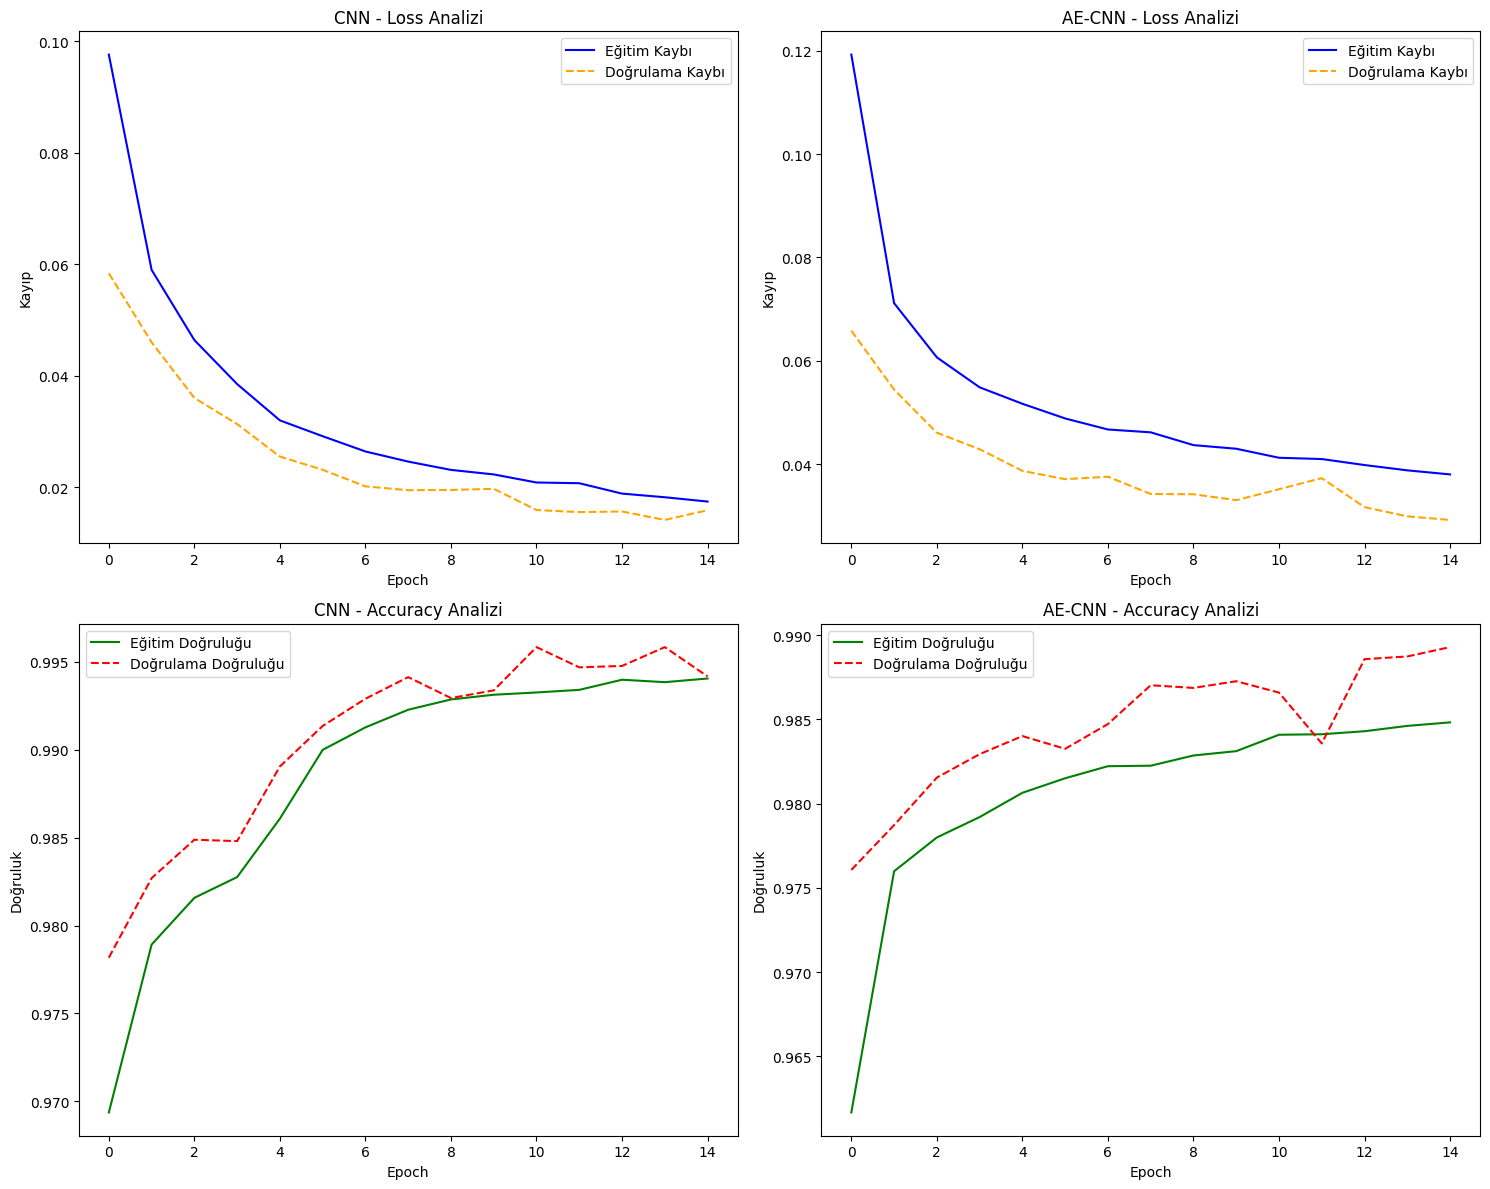

In [ ]:
# --- EĞİTİM SÜRECİ ANALİZİ  ---
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. CNN Loss Analizi
axes[0, 0].plot(history_cnn.history['loss'], label='Eğitim Kaybı', color='blue')
axes[0, 0].plot(history_cnn.history['val_loss'], label='Doğrulama Kaybı', color='orange', linestyle='--')
axes[0, 0].set_title('CNN - Loss Analizi')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Kayıp')
axes[0, 0].legend()

# 2. AE-CNN Loss Analizi
axes[0, 1].plot(history_aecnn.history['loss'], label='Eğitim Kaybı', color='blue')
axes[0, 1].plot(history_aecnn.history['val_loss'], label='Doğrulama Kaybı', color='orange', linestyle='--')
axes[0, 1].set_title('AE-CNN - Loss Analizi')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Kayıp')
axes[0, 1].legend()

# 3. CNN Accuracy Analizi
axes[1, 0].plot(history_cnn.history['accuracy'], label='Eğitim Doğruluğu', color='green')
axes[1, 0].plot(history_cnn.history['val_accuracy'], label='Doğrulama Doğruluğu', color='red', linestyle='--')
axes[1, 0].set_title('CNN - Accuracy Analizi')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Doğruluk')
axes[1, 0].legend()

# 4. AE-CNN Accuracy Analizi
axes[1, 1].plot(history_aecnn.history['accuracy'], label='Eğitim Doğruluğu', color='green')
axes[1, 1].plot(history_aecnn.history['val_accuracy'], label='Doğrulama Doğruluğu', color='red', linestyle='--')
axes[1, 1].set_title('AE-CNN - Accuracy Analizi')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Doğruluk')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# --- PERFORMANS METRİKLERİ VE KARŞILAŞTIRMA ---

In [ ]:
# Modellerden olasılıkları alıp (predict) eşik değeri (threshould) (0.5) ile 0 veya 1 sınıfına yuvarlıyoruz
cnn_preds = (cnn_model.predict(X_test_cnn) > 0.5).astype(int)
aecnn_preds = (aecnn_model.predict(X_test_encoded_cnn) > 0.5).astype(int)

def evaluate_model(y_true, y_pred, model_name):
    print(f"\n[{model_name} Modeli Performans Sonuçları]")
    print(f"Accuracy (Doğruluk):  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision (Kesinlik): {precision_score(y_true, y_pred):.4f}")
    print(f"Recall (Duyarlılık):  {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:             {f1_score(y_true, y_pred):.4f}")
    return confusion_matrix(y_true, y_pred)

cm_cnn = evaluate_model(y_test, cnn_preds, "Sadece CNN")
cm_aecnn = evaluate_model(y_test, aecnn_preds, "AE-CNN")

705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

[Sadece CNN Modeli Performans Sonuçları]
Accuracy (Doğruluk):  0.7800
Precision (Kesinlik): 0.9206
Recall (Duyarlılık):  0.6715
F1-Score:             0.7766

[AE-CNN Modeli Performans Sonuçları]
Accuracy (Doğruluk):  0.7883
Precision (Kesinlik): 0.9263
Recall (Duyarlılık):  0.6825
F1-Score:             0.7859


# --- CONFUSION MATRIX (Karmaşıklık Matrisi) GÖRSELLEŞTİRME ---

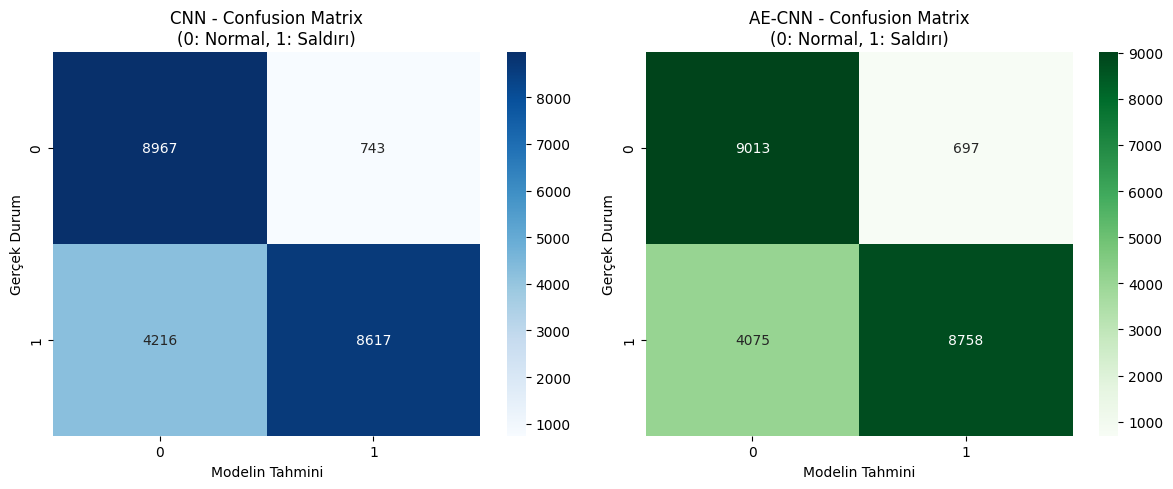

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('CNN - Confusion Matrix\n(0: Normal, 1: Saldırı)')
axes[0].set_xlabel('Modelin Tahmini')
axes[0].set_ylabel('Gerçek Durum')

sns.heatmap(cm_aecnn, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('AE-CNN - Confusion Matrix\n(0: Normal, 1: Saldırı)')
axes[1].set_xlabel('Modelin Tahmini')
axes[1].set_ylabel('Gerçek Durum')

plt.tight_layout()
plt.show()